In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/azeem1004/fake-dataset-file/Fake.csv
/kaggle/input/datasets/azeem1004/true-dataset-file/True.csv


In [2]:
#Importing Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Uploading files
true_df = pd.read_csv("/kaggle/input/datasets/azeem1004/true-dataset-file/True.csv")
fake_df = pd.read_csv("/kaggle/input/datasets/azeem1004/fake-dataset-file/Fake.csv")

# **1. Visualitization**

# **a) Statistical Analysis**

In [4]:
#true_df.head()
#fake_df.head()
#true_df.columns
#fake_df.columns

In [5]:
# Labeling datasets
true_df["label"] = 1
fake_df["label"] = 0

In [6]:
# Merging datasets
df = pd.concat([true_df, fake_df], axis=0)

In [7]:
# Shuffling Datasets
df = df.sample(frac=1).reset_index(drop=True)

In [8]:
#df.head()
df.shape

(44898, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


**The dataset contains 44,898 news articles with five features: title, text, subject, date, and label. Most columns contain textual data (object type), while the label column is numeric and represents the target variable for classification**

In [10]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [11]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

**No missing values were found in any column. Therefore, no missing data handling techniques were required.**

In [12]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64


****The dataset contains 23,481 fake news articles and 21,417 true news articles.The dataset is relatively balanced, which helps machine learning models learn both classes effectively.**


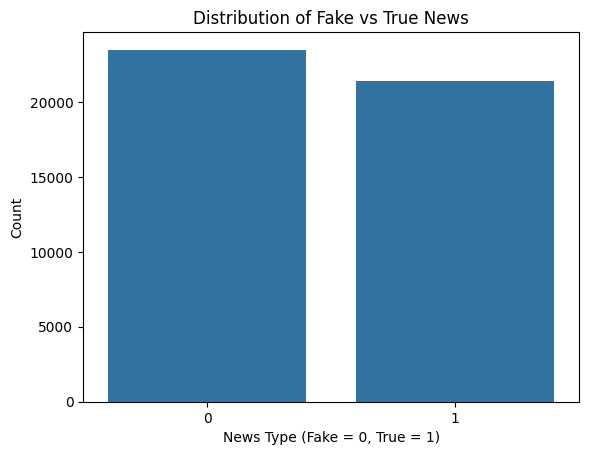

In [13]:
sns.countplot(x="label", data=df)
plt.title("Distribution of Fake vs True News")
plt.xlabel("News Type (Fake = 0, True = 1)")
plt.ylabel("Count")
plt.show()

**The dataset contains both fake and true news articles. The countplot above shows the distribution of the two classes. A balanced dataset helps machine learning models learn both classes effectively and prevents bias toward one class.**

# **b) Visual Analysis**

In [14]:
# Checking Texts Length
df["text_length"] = df["text"].apply(len)

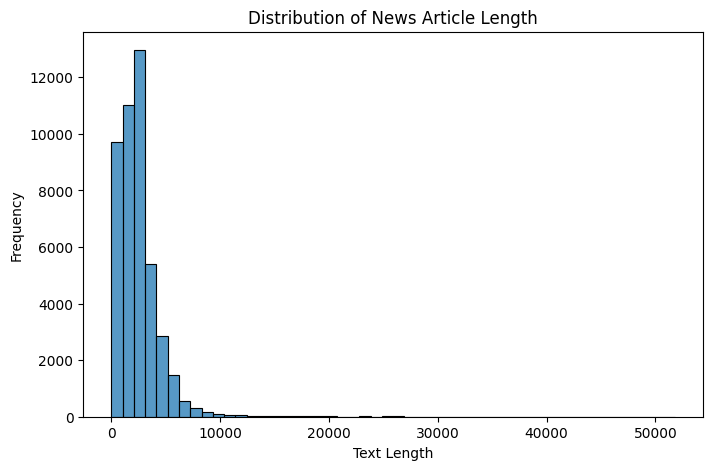

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Distribution of News Article Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

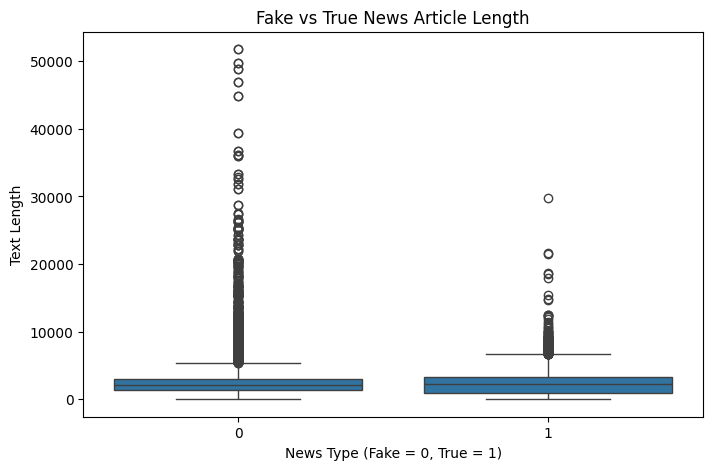

In [16]:
# Compare Fake vs True Atricles Lengths
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="text_length", data=df)
plt.title("Fake vs True News Article Length")
plt.xlabel("News Type (Fake = 0, True = 1)")
plt.ylabel("Text Length")
plt.show()

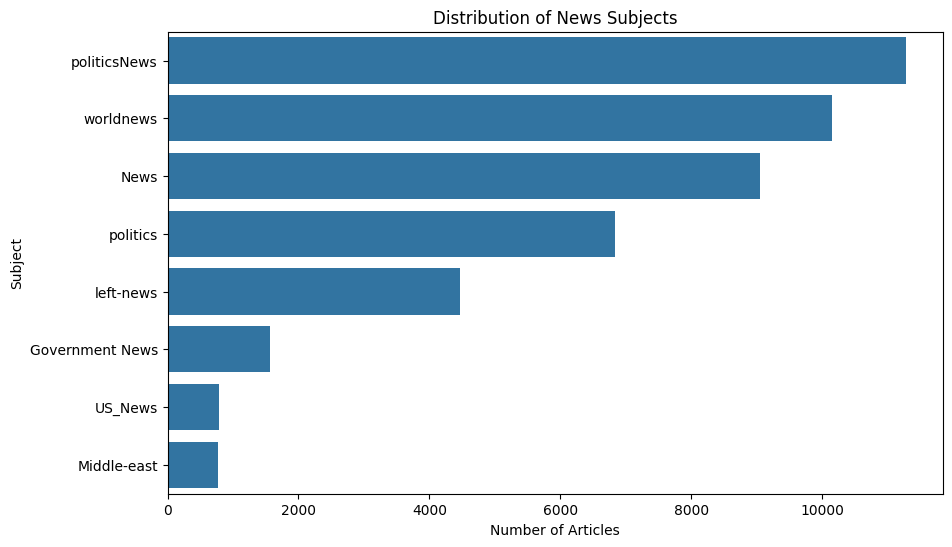

In [17]:
# This code visualizes how many news articles belong to each subject category.
# It helps us understand which topics are most common in the dataset.
plt.figure(figsize=(10,6))
sns.countplot(y="subject", data=df, order=df["subject"].value_counts().index)
plt.title("Distribution of News Subjects")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")
plt.show()

**This plot shows the number of news articles in each subject category. Some subjects appear more frequently than others, indicating that certain topics dominate the dataset. Understanding this distribution helps analyze patterns in fake news across different topics.**

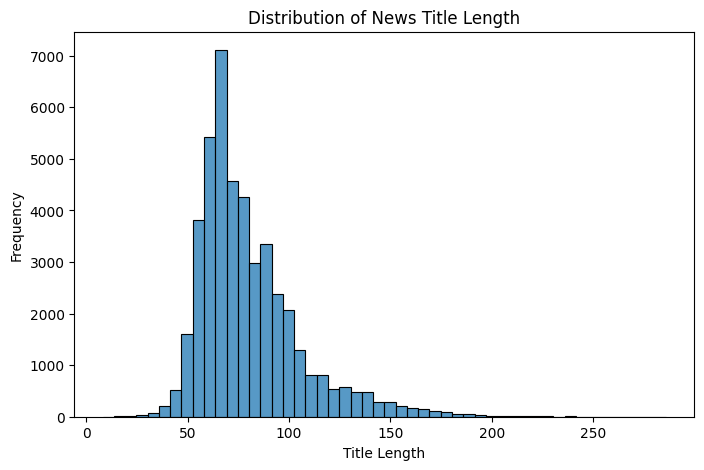

In [18]:
# This code calculates the length of each news title and visualizes the
# distribution of title lengths using a histogram.
df["title_length"] = df["title"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["title_length"], bins=50)
plt.title("Distribution of News Title Length")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

**The histogram shows the distribution of news title lengths in the dataset. Most titles fall within a moderate length range, while a few titles are significantly longer. Analyzing title length helps understand headline writing patterns that may influence fake news detection.**

# **2. Preprocessing**

In [19]:
# Convert all text to lowercase to maintain consistency in textual data
df["text"] = df["text"].str.lower()
df["title"] = df["title"].str.lower()

**All text data was converted to lowercase to ensure consistency during text processing. This prevents the model from treating words such as "News", "news", and "NEWS" as different tokens during feature extraction.**

In [20]:
import re

# Remove punctuation and special characters from text data
df["text"] = df["text"].apply(lambda x: re.sub(r"[^a-zA-Z\s]", "", x))
df["title"] = df["title"].apply(lambda x: re.sub(r"[^a-zA-Z\s]", "", x))

**Punctuation marks and special characters were removed from the text data because they do not contribute meaningful information for text classification. Removing them helps simplify the text and improves the effectiveness of feature extraction techniques.**

In [21]:
# This code removes common English stopwords from the text using sklearn

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply stopword removal
df["text"] = df["text"].apply(remove_stopwords)
df["title"] = df["title"].apply(remove_stopwords)

**Stopwords are common words such as "the", "is", "and", and "of" that appear frequently in text but provide little useful information for classification tasks. These words were removed to reduce noise in the dataset and allow the model to focus on more meaningful words that help distinguish fake news from real news.**

In [22]:
# Combine title and article text into one feature
df["content"] = df["title"] + " " + df["text"]

**The title and article text were combined into a single column called content. This allows the model to analyze both the headline and the full article simultaneously, which can improve the detection of fake news.**

In [23]:
# Remove unnecessary columns that are not required for model training

df = df.drop(["title", "text", "date"], axis=1)

**The columns title, text, and date were removed after creating the combined content feature. These columns are no longer needed for the model and removing them helps simplify the dataset and reduce unnecessary information.**

In [24]:
df.head()

,subject,label,text_length,title_length,content
0,politicsNews,1,941,56,cias brennan says tearing iran deal folly lond...
1,Middle-east,0,958,66,boiler room downtown brown loss curse celebrit...
2,politics,0,2121,177,scott baio files police report physically atta...
3,politicsNews,1,1555,52,trump order departments beef cyber security wa...
4,politics,0,1291,104,barack obama shows hes fighting terrorismrelea...


In [25]:
# Save the preprocessed dataset so it can be used in the next phase of the project

df.to_csv("processed_fake_news_dataset.csv", index=False)